In [1]:
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import optuna
import shap
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#プロットの定義
def yyplot(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=15)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    
    #plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='training set')
    #plt.scatter(m1 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='test set')
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='none', marker='o' , edgecolor='blue', alpha=0.8, s=80, label='training data')
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='red', marker='x' , alpha=0.5, s=120, label='test data')
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示  
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    
    text1 = f'r2_train={r2_train}'
    text2 = f'r2_test={r2_test}'
    
    plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')

In [3]:
all_data = pd.read_csv('231202_tateishi_a-glucosidase_rdkit.csv')
seed_list = pd.read_csv("../datasets/split_seed_result.csv")["seed"]

train, test = train_test_split(all_data, test_size=0.2, random_state=seed_list[45])

all_variables =train.columns.values
len(all_variables), len(all_data)

(184, 433)

In [4]:
variables = all_variables[6:]
len(variables)

178

In [5]:
#trainig用説明変数
X_train = train[variables]
X_test = test[variables]
X_all = all_data[variables]
x_ori = X_train.columns.values

#test用目的変数
Y_train = train['pIC50']
Y_train=pd.DataFrame(Y_train)
Y_test = test['pIC50']
Y_test=pd.DataFrame(Y_test)
Y_all = all_data['pIC50']
Y_all=pd.DataFrame(Y_all)

#変数の標準化
#ddof=0 標準偏差 ddof=1 不偏標準偏差
ddof = 0

#説明変数についての標準偏差と平均値
mean_train_x = X_train.mean()
std_train_x = X_train.std(ddof = ddof)
mean_test_x = X_test.mean()
std_test_x = X_test.std(ddof = ddof)
mean_all_x = X_all.mean()
std_all_x = X_all.std(ddof = ddof)

#目的変数についての標準偏差と平均値
mean_train_y =Y_train.mean()
std_train_y = Y_train.std(ddof = ddof)
mean_test_y = Y_test.mean()
std_test_y = Y_test.std(ddof = ddof)
mean_all_y = Y_all.mean()
std_all_y = Y_all.std(ddof = ddof)

#標準化
X_train_std = (X_train - mean_train_x) / (std_train_x)
X_test_std = (X_test - mean_test_x) / (std_test_x)
Y_train_std = (Y_train - mean_train_y) / (std_train_y)
Y_test_std = (Y_test - mean_test_y) / (std_test_y)
X_all_std = (X_all - mean_all_x) / (std_all_x)
Y_all_std = (Y_all - mean_all_y) / (std_all_y)

X_train = X_train_std
X_test = X_test_std 
Y_train = Y_train_std
Y_test = Y_test_std
X_all = X_all_std
Y_all = Y_all_std

#標準化済み確認
len(Y_train_std),len(Y_test_std),len(Y_all_std)

(346, 87, 433)

In [6]:
X_all = all_data[variables]
X_all.shape

(433, 178)

In [7]:
dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)
dall = xgb.DMatrix(X_all, label=Y_all)

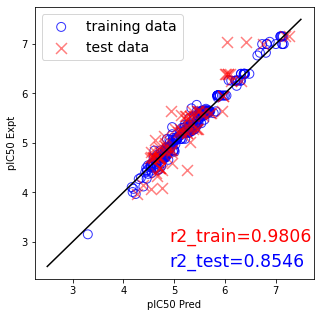

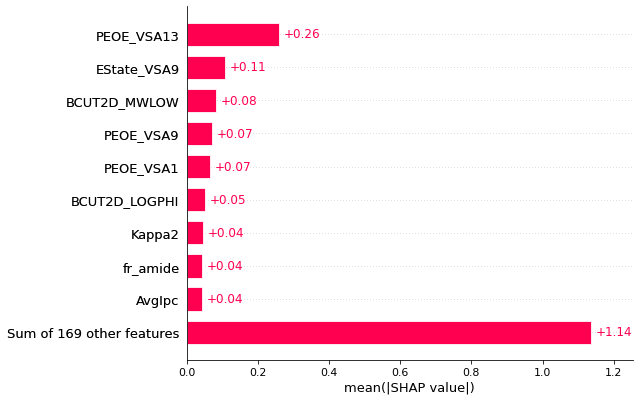

In [10]:
model = xgb.Booster()
model.load_model('best_model/rdkit_model_45.json')

#プロットの作成
yyplot(model, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result_letteryy_plot_T_"+str(i)+".png")
#plt.savefig("result/yy_plot_best_model.png")
plt.savefig("best_model/論文用_yy_plot_best_model.png")

# SHAP値を計算するためのexplainerを作成
explainer = shap.TreeExplainer(
    model = model,  # 学習済みモデル
    feature_perturbation="interventional"  # 推奨
    )
# SHAP値を計算
shap_values = explainer(X_train, Y_train)

# 棒グラフで重要度を可視化
fig2 = plt.figure(figsize=(5,5))   #新しいウィンドウを描画
fig2.subplots()
shap.plots.bar(shap_values=shap_values, max_display=10, show=False)
#fig2.savefig("result/shap_best_model.png") # 画像を保存
fig2.savefig("best_model/論文用_shap_best_model.png") # 画像を保存

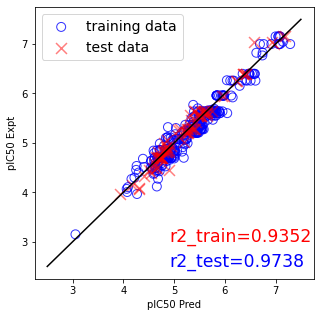

In [13]:
#再学習
model = xgb.Booster()
model.load_model('best_model/rdkit_model_45.json')

n_estimators = 10000
random_state = 0
max_depth = 4
max_leaves = 5
colsample_bytree = 0.8001987643312883
colsample_bylevel = 0.6473824757754867
colsample_bynode = 0.7492206366155216
subsample = 0.9686526402396832
reg_lambda = 0.0003316572784089958
reg_alpha = 0.704594891004046
leraning_rate = 3.419609942708125
gamma = 0.11650539174139507

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    "booster":  "gbtree",
    'verbosity' : 0,
    'random_state' : randam_state,
    'n_estimators' : 10000,
    'base_score' : float(Y_all.mean().values), 
    'max_depth': max_depth, 
    'max_leaves':max_leaves,
    'colsample_bytree': colsample_bytree,
    'colsample_byrevel': colsample_bylevel,
    'colsample_bynode': colsample_bynode,
    'subsample': subsample,
    "reg_lambda": reg_lambda,
    "reg_alpha": reg_alpha,
    "leraning_rate" : leraning_rate,
    "gamma" : gamma,
}

dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)
evals = [(dtest, 'eval'), (dtrain, 'train')]

#モデルを再学習
model_pro = xgb.train(params=params,
                      xgb_model=model,
                      dtrain=dtest,
                      num_boost_round=10000,
                      early_stopping_rounds=100,
                      evals=evals, 
                      verbose_eval=False,
                         )

# with構文でファイルパスとバイナリ書き込みモードを設定
with open("best_model/rdkit_model_pro"+".pickle", mode='wb') as f:
    pickle.dump(model_pro, f)
model_pro.save_model("best_model/rdkit_model_pro.json")

#プロットの作成
yyplot(model_pro, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result/yy_plot_model_pro.png")

In [14]:
m3, s3 = mean_all_y, std_all_y
m3, s3

(pIC50    5.277669
 dtype: float64,
 pIC50    0.65642
 dtype: float64)

In [15]:
m2, s2 = mean_test_y, std_test_y
m2, s2

(pIC50    5.277672
 dtype: float64,
 pIC50    0.717034
 dtype: float64)

In [16]:
dall = xgb.DMatrix(X_all, label=Y_all)
all_pred = pd.DataFrame(model_pro.predict(dall), columns=['pIC50'])

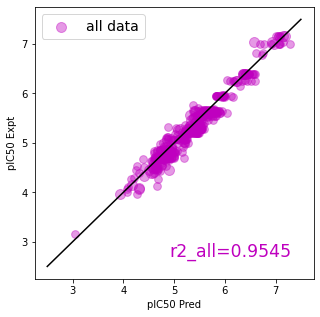

In [17]:
#プロットの定義
def yyplot_pro(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    m3, s3 = mean_all_y, std_all_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=15)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    #all_pred = pd.DataFrame(model.predict(X_all), columns=['pIC50'])
    
    #plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='training set')
    #plt.scatter(m1 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='test set')
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='m', marker='o' , alpha=0.4, s=60)
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='m', marker='o' , alpha=0.4, s=100,  label='all data')
    #plt.scatter(m3 + all_pred*s3, m3 + Y_all*s3, color='m', marker='o' , alpha=0.4)
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示  
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    r2_all = (r2_train + r2_test)/2
    
    #text1 = f'r2_train={r2_train}'
    #text2 = f'r2_test={r2_test}'
    text3 = f'r2_all={r2_all}'
    
    #plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    #plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')
    plt.text(4.9, 2.7, text3, fontsize="xx-large", color='m')

#プロットの作成
yyplot_pro(model_pro, Y_test, dtest, Y_train, dtrain, "")
plt.savefig("best_model/論文用_yy_plot_model_pro.png")

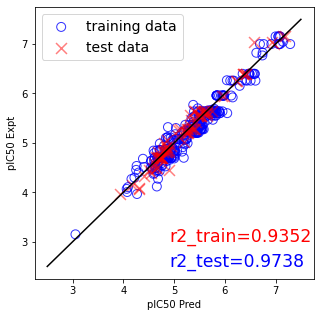

In [19]:
model_pro = xgb.Booster()
model_pro.load_model('best_model/rdkit_model_pro.json')
yyplot(model_pro, Y_test, dtest, Y_train, dtrain, "")

In [21]:
kampo = pd.read_csv('231207_tateishi_kampo_rdkit.csv', index_col=0)
kampo = kampo.dropna(how='any').reset_index()
#kampo = kampo.drop_duplicates(subset='smiles')
all_variables =kampo.columns.values
all_variables
#kampo

array(['number', 'cid', 'name', 'smiles', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons',
       'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge',
       'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2',
       'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI',
       'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI',
       'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n',
       'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n',
       'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1',
       'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10',
       'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14',
       'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6',
       'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10',
       'SMR_VSA2', 'SMR_V

In [22]:
len(kampo)

2646

In [23]:
#trainig用説明変数
X_kampo = kampo[variables]

#変数の標準化
#ddof=0 標準偏差 ddof=1 不偏標準偏差
ddof = 0

#標準化
X_kampo_std = (X_kampo - mean_train_x) / (std_train_x)
X_kampo_std = X_kampo_std.replace([np.inf, -np.inf], np.nan)

X_kampo = X_kampo_std

#標準化済み確認
len(X_kampo)

2646

In [24]:
#プロットの定義
def yyplot_kampo(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=20)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    dkampo = xgb.DMatrix(X_kampo)
    kampo_pred = pd.DataFrame(model.predict(dkampo), columns=['pIC50'])
    #kampo_pred = kampo_pred.sort_values('pIC50', ascending=False)
    kampo_pred =m1 + kampo_pred*s1
    
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='Training Data')
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='Test Data')
    #plt.scatter(6.44, 6.85, color='green', marker='*',s= 500, label='natural')
    plt.scatter(kampo_pred, len(kampo_pred)*[5], color='green', marker='*',s= 10, label='natural')
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示  
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    
    text1 = f'r2_train={r2_train}'
    text2 = f'r2_test={r2_test}'
    
    plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')
    
    #plt.rcParams["font.size"] = 15

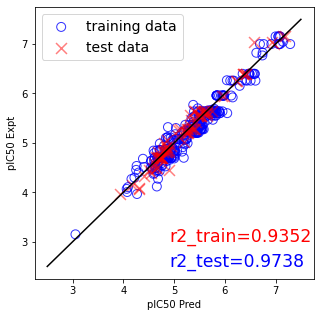

In [25]:
#Predict
train_pred2 = pd.DataFrame(model_pro.predict(dtrain), columns=['pIC50'])
test_pred2 = pd.DataFrame(model_pro.predict(dtest), columns=['pIC50'])

#R2
m1, s1 = mean_train_y, std_train_y
m2, s2 = mean_test_y, std_test_y
r2_train = r2_score(m1 + Y_train*s1, m1 + train_pred2*s1).round(4)
r2_test = r2_score(m2 + Y_test*s2, m2 + test_pred2*s2).round(4)

#プロットの作成
yyplot(model_pro, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result_letteryy_plot_T_"+str(i)+".png")
#plt.savefig("result_letter/yy_plot_pro.png")

# SHAP値を計算するためのexplainerを作成
explainer = shap.TreeExplainer(
    model = model_pro,  # 学習済みモデル
    feature_perturbation="interventional"  # 推奨
    )
# SHAP値を計算
shap_values = explainer(X_train, Y_train)

# 棒グラフで重要度を可視化
#fig2 = plt.figure(figsize=(5,5))   #新しいウィンドウを描画
#fig2.subplots()
#shap.plots.bar(shap_values=shap_values, max_display=len(desc_list2), show=False)
#fig2.savefig("result_lettershap_pro.png") # 画像を保存

In [26]:
len(X_kampo.columns)

178

In [27]:
dkampo = xgb.DMatrix(X_kampo)
kampo_pred = pd.DataFrame(model_pro.predict(dkampo), columns=['pIC50'])

In [28]:
m, s = mean_train_y, std_train_y
kampo_pred = m + kampo_pred*s
kampo_pred

,pIC50
0,5.055443
1,3.613468
2,5.306270
3,4.975612
4,4.160165
...,...
2641,4.524577
2642,5.061842
2643,5.115325
2644,4.806760


In [29]:
df_sort = kampo_pred.sort_values('pIC50', ascending=False)
len(df_sort)
df_sort

,pIC50
1781,5.975657
260,5.817964
2327,5.814650
1004,5.720993
929,5.628597
...,...
1256,3.319761
1307,3.240762
1841,3.227937
607,3.200499


In [31]:
result = pd.concat([kampo_pred.reset_index(), kampo.reset_index()], axis=1)
result.to_csv('virtual_screening_result/kampo_virtual_screening_rdkit_result_1207.csv')

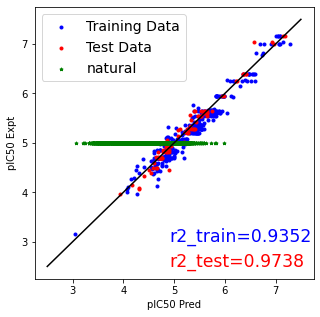

In [32]:
yyplot_kampo(model_pro, Y_test, dtest, Y_train, dtrain, "")